# 04. Visualização dos Dados (EDA)
# CRISP-DM — Fase 3: Análise dos Dados

Análise exploratória visual do dataset tratado (`dados_tratados.csv`).  
Objetivo: entender a distribuição das variáveis e a relação com o target `IDEB_2025`  
antes de partir para a modelagem.


## 1. Importação das Bibliotecas

In [2]:
# CRISP-DM: análise de dados fase 3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


## 2. Carregamento do Dataset Tratado

In [3]:
# CRISP-DM: preparação de dados fase 3
CAMINHO_CSV = '../datasets/dados_tratados.csv'

def carregarDados(caminho):
    dados = None
    try:
        dados = pd.read_csv(caminho, sep=';', encoding='utf-8-sig')
        print("Dataset carregado com sucesso!")
        print(f"  Registros : {dados.shape[0]:,}")
        print(f"  Colunas   : {dados.shape[1]}")
    except Exception as e:
        print(f"Não foi possível carregar os dados: {e}")
    return dados

df = carregarDados(CAMINHO_CSV)


Dataset carregado com sucesso!
  Registros : 17,583
  Colunas   : 227


## 3. Inspeção Inicial dos Dados

In [4]:
# Retorna dados básicos sobre o dataset carregado
print("=== INFO ===")
print(df.info())

print("\n=== PRIMEIROS REGISTROS ===")
print(df.head())

print("\n=== ÚLTIMOS REGISTROS ===")
print(df.tail())

print("\n=== ESTATÍSTICAS BÁSICAS ===")
print(df.describe())


=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 17583 entries, 0 to 17582
Columns: 227 entries, SG_UF to IDEB_2025
dtypes: float64(221), int64(4), str(2)
memory usage: 30.5 MB
None

=== PRIMEIROS REGISTROS ===
  SG_UF  CO_UF                                       NO_ENTIDADE  CO_ENTIDADE  \
0    RO     11           EEEMTI JUSCELINO KUBITSCHEK DE OLIVEIRA     11024968   
1    RO     11   COLEGIO TIRADENTES DA POLICIA MILITAR - CTPM XI     11025638   
2    RO     11                               EEEFM CORA CORALINA     11006773   
3    RO     11                             EEEFM ANISIO TEIXEIRA     11006889   
4    RO     11  COLEGIO TIRADENTES DA POLICIA MILITAR - CTPM III     11007168   

   TP_DEPENDENCIA  TP_LOCALIZACAO  IN_LOCAL_FUNC_PREDIO_ESCOLAR  \
0               2               1                           1.0   
1               2               1                           1.0   
2               2               1                           1.0   
3               2              

## 4. Distribuição do Target — IDEB_2025

Análise da variável que queremos prever: a nota do IDEB das escolas públicas
de ensino médio. Entender sua distribuição é fundamental para escolher os
modelos e interpretar as métricas de erro.


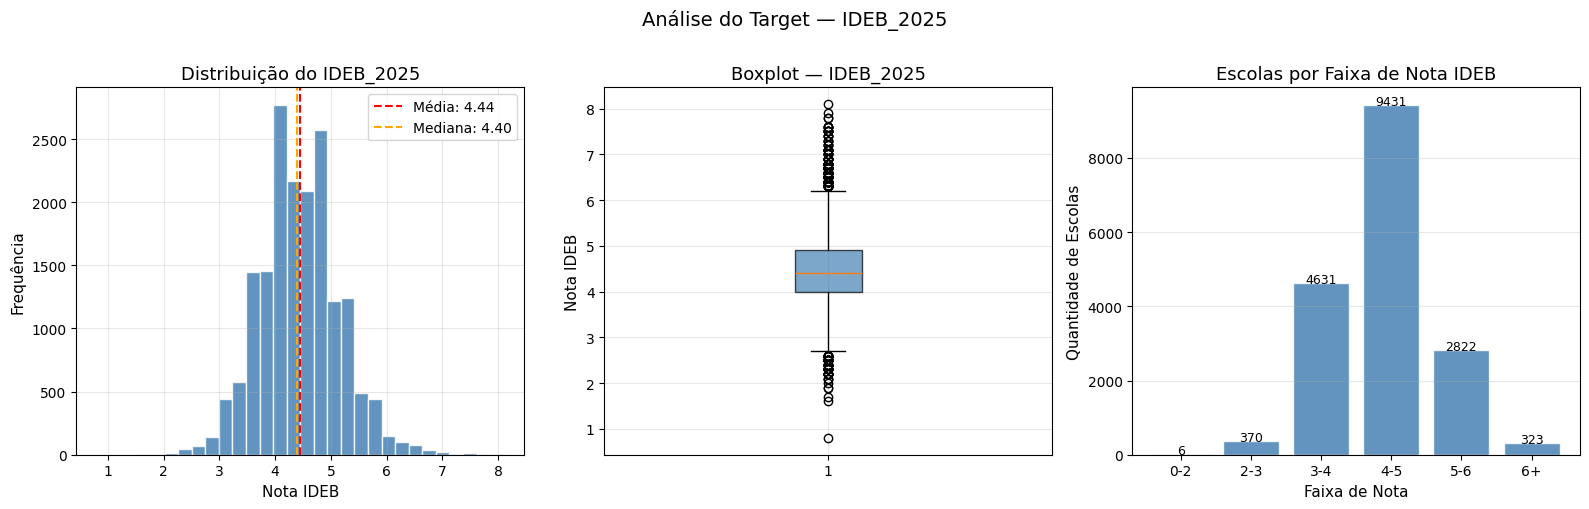

Estatísticas do IDEB_2025:
count    17583.000
mean         4.441
std          0.711
min          0.800
25%          4.000
50%          4.400
75%          4.900
max          8.100


In [5]:
def visualizarDistribuicaoTarget(dados, coluna='IDEB_2025'):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Histograma
    axes[0].hist(
        dados[coluna].dropna(),
        bins=30,
        color='steelblue',
        edgecolor='white',
        alpha=0.85
    )
    axes[0].axvline(
        dados[coluna].mean(),
        color='red',
        linestyle='--',
        label=f"Média: {dados[coluna].mean():.2f}"
    )
    axes[0].axvline(
        dados[coluna].median(),
        color='orange',
        linestyle='--',
        label=f"Mediana: {dados[coluna].median():.2f}"
    )
    axes[0].set_title(f'Distribuição do {coluna}', fontsize=13)
    axes[0].set_xlabel('Nota IDEB', fontsize=11)
    axes[0].set_ylabel('Frequência', fontsize=11)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Boxplot
    axes[1].boxplot(
        dados[coluna].dropna(),
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.7)
    )
    axes[1].set_title(f'Boxplot — {coluna}', fontsize=13)
    axes[1].set_ylabel('Nota IDEB', fontsize=11)
    axes[1].grid(True, alpha=0.3)

    # Distribuição por faixa de nota
    faixas = pd.cut(
        dados[coluna].dropna(),
        bins=[0, 2, 3, 4, 5, 6, 10],
        labels=['0-2', '2-3', '3-4', '4-5', '5-6', '6+']
    )
    contagem = faixas.value_counts().sort_index()

    axes[2].bar(
        contagem.index.astype(str),
        contagem.values,
        color='steelblue',
        edgecolor='white',
        alpha=0.85
    )
    axes[2].set_title('Escolas por Faixa de Nota IDEB', fontsize=13)
    axes[2].set_xlabel('Faixa de Nota', fontsize=11)
    axes[2].set_ylabel('Quantidade de Escolas', fontsize=11)
    axes[2].grid(True, alpha=0.3, axis='y')

    for i, v in enumerate(contagem.values):
        axes[2].text(i, v + 5, str(v), ha='center', fontsize=9)

    plt.suptitle('Análise do Target — IDEB_2025', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig('../imagens/distribuicao_target.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Estatísticas do {coluna}:")
    print(dados[coluna].describe().round(3).to_string())

visualizarDistribuicaoTarget(df)


## 5. Boxplot das Variáveis Numéricas

Visualização da dispersão das principais variáveis quantitativas do Censo Escolar.
Boxplots revelam outliers, assimetria e amplitude de cada variável.


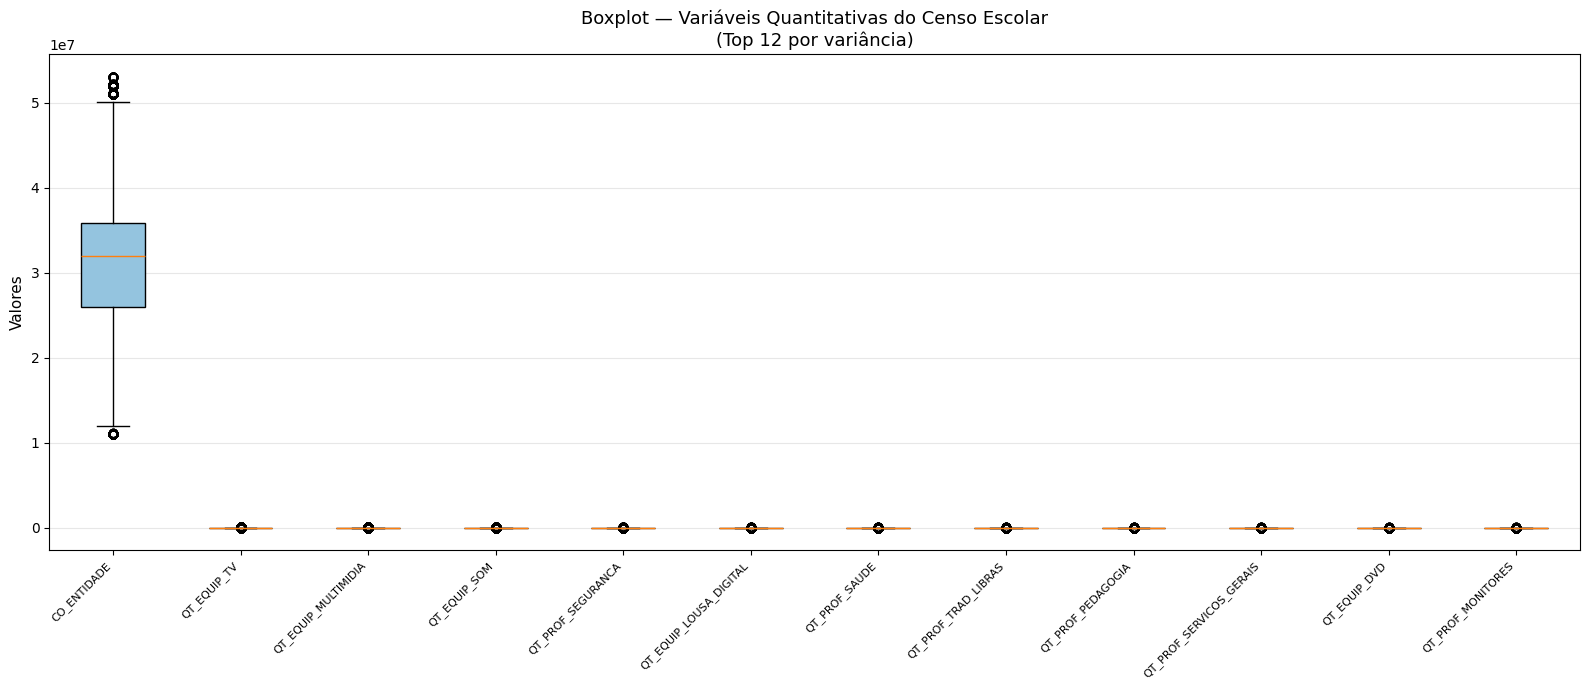

Variáveis exibidas no boxplot:
  CO_ENTIDADE                              média=32219089.7  std=9588211.9
  QT_EQUIP_TV                              média=4111.0  std=18654.7
  QT_EQUIP_MULTIMIDIA                      média=2137.4  std=13604.1
  QT_EQUIP_SOM                             média=624.2  std=7408.4
  QT_PROF_SEGURANCA                        média=223.4  std=4441.1
  QT_EQUIP_LOUSA_DIGITAL                   média=91.8  std=2842.6
  QT_PROF_SAUDE                            média=75.9  std=2595.2
  QT_PROF_TRAD_LIBRAS                      média=45.6  std=2010.6
  QT_PROF_PEDAGOGIA                        média=38.4  std=1773.2
  QT_PROF_SERVICOS_GERAIS                  média=40.8  std=1773.2
  QT_EQUIP_DVD                             média=31.0  std=1641.8
  QT_PROF_MONITORES                        média=25.8  std=1498.8


In [6]:
def gerarBoxplot(dados):
    # Selecionar colunas quantitativas (não binárias) com maior variância
    colunas_qt = [
        c for c in dados.select_dtypes(include=[np.number]).columns
        if dados[c].max() > 1 and c != 'IDEB_2025'
    ]

    colunas_qt = sorted(
        colunas_qt,
        key=lambda c: dados[c].var(),
        reverse=True
    )[:12]

    fig, ax = plt.subplots(figsize=(16, 7))
    ax.set_title(
        'Boxplot — Variáveis Quantitativas do Censo Escolar\n(Top 12 por variância)',
        fontsize=13
    )
    ax.set_ylabel('Valores', fontsize=11)

    dados_plot = [dados[col].dropna().values for col in colunas_qt]
    bp = ax.boxplot(
        dados_plot,
        patch_artist=True,
        positions=range(1, len(colunas_qt) + 1)
    )

    cores = plt.cm.Blues(np.linspace(0.4, 0.85, len(colunas_qt)))
    for patch, cor in zip(bp['boxes'], cores):
        patch.set_facecolor(cor)

    ax.set_xticks(range(1, len(colunas_qt) + 1))
    ax.set_xticklabels(colunas_qt, rotation=45, ha='right', fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('../imagens/boxplot_variaveis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Variáveis exibidas no boxplot:")
    for col in colunas_qt:
        print(
            f"  {col:<40} "
            f"média={dados[col].mean():.1f}  "
            f"std={dados[col].std():.1f}"
        )

gerarBoxplot(df)


## 6. Distribuição das Variáveis Binárias (IN_*)

A maioria das variáveis do Censo Escolar são binárias (0 = Não / 1 = Sim).
Visualizamos a proporção de escolas com cada recurso/característica.


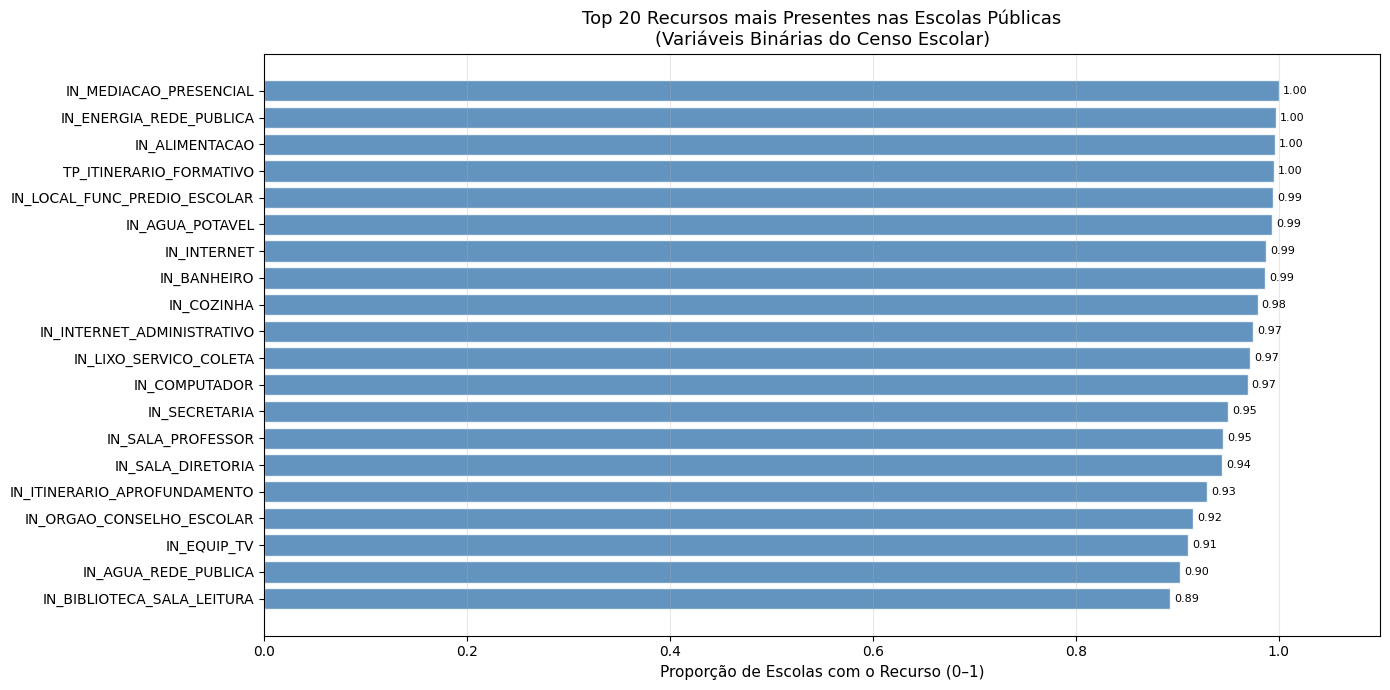

Total de variáveis binárias no dataset: 164
Top 5 recursos mais presentes:
IN_MEDIACAO_PRESENCIAL          1.000
IN_ENERGIA_REDE_PUBLICA         0.998
IN_ALIMENTACAO                  0.996
TP_ITINERARIO_FORMATIVO         0.996
IN_LOCAL_FUNC_PREDIO_ESCOLAR    0.995

Top 5 recursos menos presentes:
IN_ITINERARIO_APROFUNDAMENTO    0.930
IN_ORGAO_CONSELHO_ESCOLAR       0.916
IN_EQUIP_TV                     0.911
IN_AGUA_REDE_PUBLICA            0.903
IN_BIBLIOTECA_SALA_LEITURA      0.893


In [7]:
def visualizarVariaveisBinarias(dados, top_n=20):
    # Selecionar colunas binárias (apenas 0 e 1)
    cols_bin = [
        c for c in dados.select_dtypes(include=[np.number]).columns
        if set(dados[c].dropna().unique()).issubset({0, 1})
        and c != 'IDEB_2025'
    ]

    # Calcular proporção de '1' e ordenar
    proporcoes = (
        dados[cols_bin]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(14, 7))
    bars = plt.barh(
        proporcoes.index[::-1],
        proporcoes.values[::-1],
        color='steelblue',
        edgecolor='white',
        alpha=0.85
    )
    plt.xlabel('Proporção de Escolas com o Recurso (0–1)', fontsize=11)
    plt.title(
        f'Top {top_n} Recursos mais Presentes nas Escolas Públicas\n'
        '(Variáveis Binárias do Censo Escolar)',
        fontsize=13
    )
    plt.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)
    plt.xlim(0, 1.1)
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(
        '../imagens/proporcao_variaveis_binarias.png',
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()

    print(f"Total de variáveis binárias no dataset: {len(cols_bin)}")
    print("Top 5 recursos mais presentes:")
    print(proporcoes.head(5).round(3).to_string())

    print("\nTop 5 recursos menos presentes:")
    print(proporcoes.tail(5).round(3).to_string())

visualizarVariaveisBinarias(df)


## 7. Média do IDEB por Unidade da Federação

Comparação regional do desempenho médio das escolas públicas de ensino médio,
permitindo identificar disparidades entre estados.


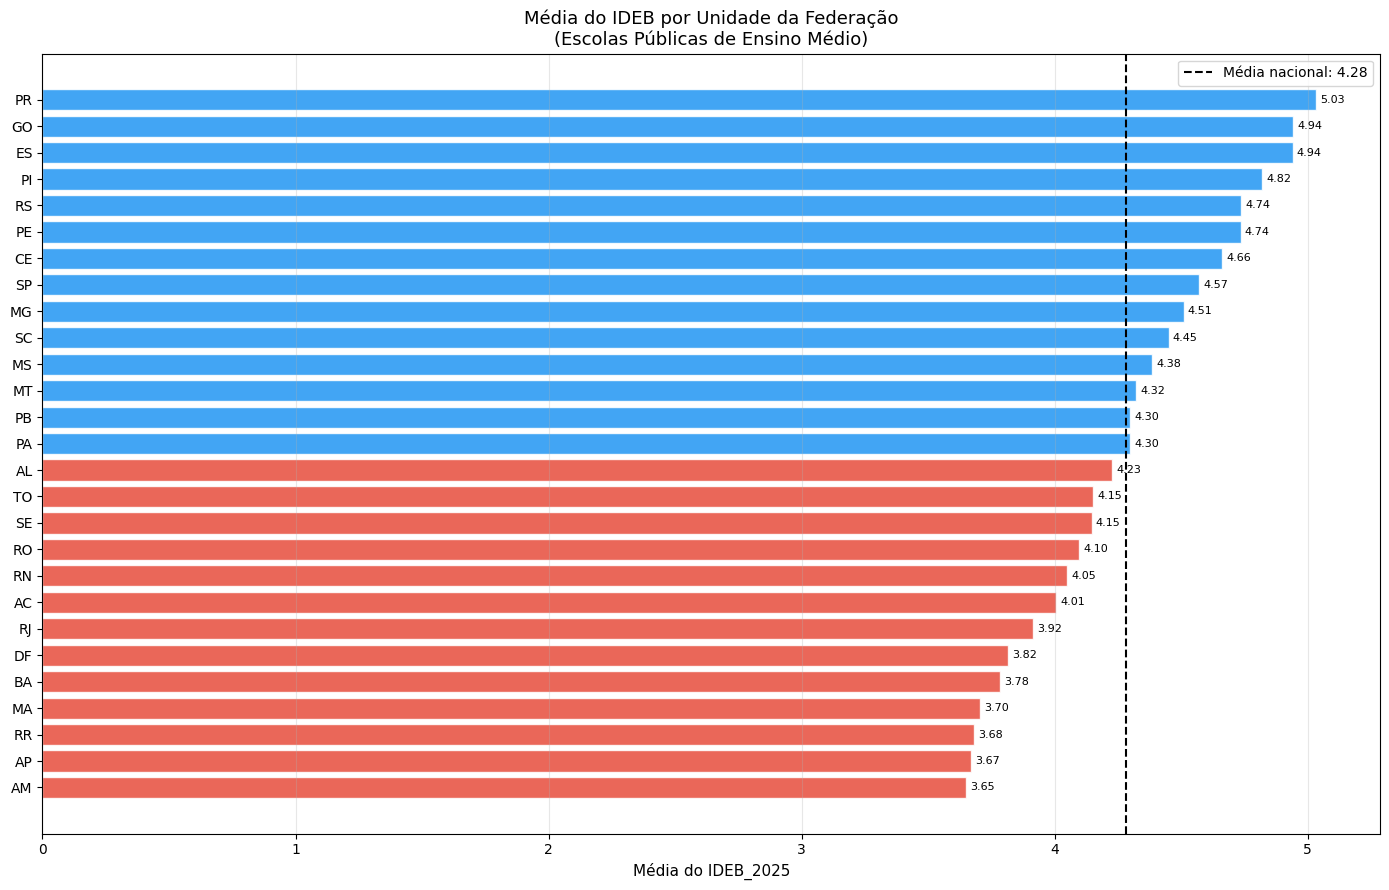

Vermelho = abaixo da média nacional | Azul = acima

Top 5 UFs com maior IDEB médio:
SG_UF  Media_IDEB  N_Escolas
   PR    5.034013       1373
   GO    4.942313        683
   ES    4.940520        269
   PI    4.818977        469
   RS    4.738380        938

Top 5 UFs com menor IDEB médio:
SG_UF  Media_IDEB  N_Escolas
   AM    3.650476        315
   AP    3.670330         91
   RR    3.682222         45
   MA    3.703714        700
   BA    3.783172       1034


In [8]:
def graficoBarrasIdebrPorUF(dados):
    if 'SG_UF' not in dados.columns:
        print("Coluna SG_UF não encontrada no dataset.")
        return

    media_uf = (
        dados.groupby('SG_UF')['IDEB_2025']
        .agg(['mean', 'count'])
        .reset_index()
        .rename(columns={'mean': 'Media_IDEB', 'count': 'N_Escolas'})
        .sort_values('Media_IDEB', ascending=True)
    )

    fig, ax = plt.subplots(figsize=(14, 9))
    cores = [
        '#e74c3c' if v < media_uf['Media_IDEB'].mean() else '#2196F3'
        for v in media_uf['Media_IDEB']
    ]

    bars = ax.barh(
        media_uf['SG_UF'],
        media_uf['Media_IDEB'],
        color=cores,
        edgecolor='white',
        alpha=0.85
    )

    ax.axvline(
        media_uf['Media_IDEB'].mean(),
        color='black',
        linestyle='--',
        linewidth=1.5,
        label=f"Média nacional: {media_uf['Media_IDEB'].mean():.2f}"
    )

    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)
    ax.set_xlabel('Média do IDEB_2025', fontsize=11)
    ax.set_title(
        'Média do IDEB por Unidade da Federação\n'
        '(Escolas Públicas de Ensino Médio)',
        fontsize=13
    )
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.savefig('../imagens/ideb_por_uf.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("Vermelho = abaixo da média nacional | Azul = acima")

    print("\nTop 5 UFs com maior IDEB médio:")
    print(
        media_uf
        .sort_values('Media_IDEB', ascending=False)
        .head(5)[['SG_UF', 'Media_IDEB', 'N_Escolas']]
        .to_string(index=False)
    )

    print("\nTop 5 UFs com menor IDEB médio:")
    print(
        media_uf
        .sort_values('Media_IDEB')
        .head(5)[['SG_UF', 'Media_IDEB', 'N_Escolas']]
        .to_string(index=False)
    )

graficoBarrasIdebrPorUF(df)


## 8. Scatter Plot — IDEB vs Variáveis-Chave

Visualização da relação entre o IDEB e as features mais correlacionadas,
identificando padrões e tendências que os modelos deverão capturar.


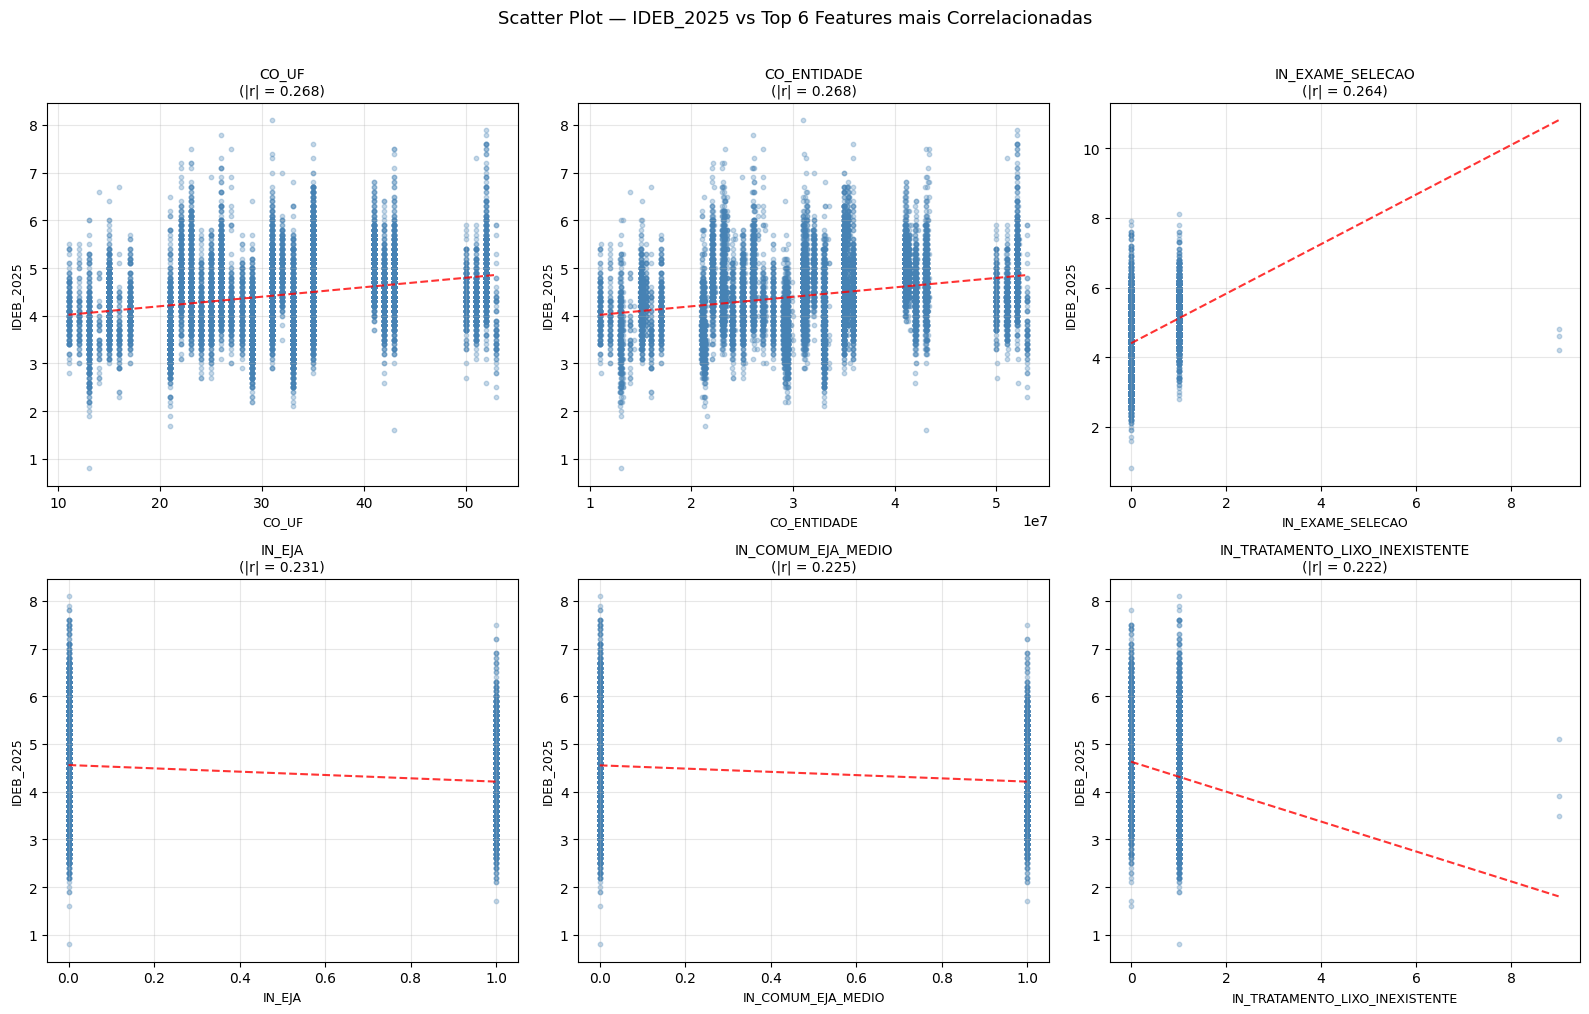

Features exibidas (correlação com IDEB_2025):
CO_UF                             0.268
CO_ENTIDADE                       0.268
IN_EXAME_SELECAO                  0.264
IN_EJA                            0.231
IN_COMUM_EJA_MEDIO                0.225
IN_TRATAMENTO_LIXO_INEXISTENTE    0.222


In [9]:
def scatterIdebVsFeatures(dados, n_features=6):
    # Selecionar features mais correlacionadas com o IDEB
    numericas = dados.select_dtypes(include=[np.number]).dropna()

    correlacoes = numericas.corrwith(
        numericas['IDEB_2025']
    ).abs()

    correlacoes = (
        correlacoes
        .drop('IDEB_2025')
        .sort_values(ascending=False)
    )

    top_features = correlacoes.head(n_features).index.tolist()

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for i, col in enumerate(top_features):
        axes[i].scatter(
            dados[col],
            dados['IDEB_2025'],
            alpha=0.3,
            s=10,
            color='steelblue'
        )

        # Linha de tendência
        mask = dados[[col, 'IDEB_2025']].notna().all(axis=1)

        z = np.polyfit(
            dados.loc[mask, col],
            dados.loc[mask, 'IDEB_2025'],
            1
        )
        p = np.poly1d(z)

        x_line = np.linspace(
            dados[col].min(),
            dados[col].max(),
            100
        )

        axes[i].plot(
            x_line,
            p(x_line),
            'r--',
            linewidth=1.5,
            alpha=0.8
        )

        corr_val = correlacoes[col]

        axes[i].set_title(
            f'{col}\n(|r| = {corr_val:.3f})',
            fontsize=10
        )
        axes[i].set_xlabel(col, fontsize=9)
        axes[i].set_ylabel('IDEB_2025', fontsize=9)
        axes[i].grid(True, alpha=0.3)

    plt.suptitle(
        'Scatter Plot — IDEB_2025 vs Top 6 Features mais Correlacionadas',
        fontsize=13,
        y=1.01
    )
    plt.tight_layout()
    plt.savefig(
        '../imagens/scatter_ideb_features.png',
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()

    print("Features exibidas (correlação com IDEB_2025):")
    print(correlacoes.head(n_features).round(3).to_string())

scatterIdebVsFeatures(df)


## 9. Execução Consolidada — visualizarDados()

Função principal que chama todas as visualizações em sequência,
no padrão do projeto.


In [10]:
# CRISP-DM: análise de dados fase 3
def visualizarDados(dados):
    print("\n" + "=" * 55)
    print("  VISUALIZAÇÃO DOS DADOS — EDA")
    print("=" * 55)

    print("\n[1/5] Distribuição do target IDEB_2025...")
    visualizarDistribuicaoTarget(dados)

    print("\n[2/5] Boxplot das variáveis quantitativas...")
    gerarBoxplot(dados)

    print("\n[3/5] Proporção das variáveis binárias...")
    visualizarVariaveisBinarias(dados)

    print("\n[4/5] Média do IDEB por UF...")
    graficoBarrasIdebrPorUF(dados)

    print("\n[5/5] Scatter IDEB vs features-chave...")
    scatterIdebVsFeatures(dados)

    print("\n✅ Visualização concluída!")

# Executar visualizarDados(df)


---
## Conclusão

| Visualização | Insight |
|---|---|
| Distribuição do IDEB | Ver seção 4 — faixa predominante e dispersão |
| Boxplot variáveis | Ver seção 5 — outliers e escalas diferentes entre features |
| Variáveis binárias | Ver seção 6 — recursos mais e menos presentes nas escolas |
| IDEB por UF | Ver seção 7 — disparidades regionais |
| Scatter features-chave | Ver seção 8 — relações não-lineares entre features e IDEB |

> **Próximo passo:** `05.Modelagem_Avaliacao.ipynb`  
> Separação dos dados, treinamento dos modelos, avaliação e salvamento.
